# SegTHOR: Quantitative inspection

## Setup

In [4]:
from pathlib import Path
import csv
import json
import platform
from datetime import datetime, timezone
import nibabel as nib
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

RAW_ROOT = Path("data/segthor_part1/train")
OUTPUT = Path(".")

VALIDATION_IDS = {"Patient_01", "Patient_08", "Patient_11", "Patient_12", "Patient_16"} # match snellius split
LABEL_NAMES = {0: "Background", 1: "Merged esophagus + aorta", 2: "Heart", 3: "Trachea", 4: "Separate aorta label"}
print("Input:", RAW_ROOT)
print("Python:", platform.python_version(), "NumPy:", np.__version__, "NiBabel:", nib.__version__)
print("Split membership is taken from the group's supplied notes.")

from IPython.display import display, Image


Input: data/segthor_part1/train
Python: 3.10.21 NumPy: 2.2.6 NiBabel: 5.4.2
Split membership is taken from the group's supplied notes.


## Analysis

### 1. Inventory and geometry

In [5]:
patients = []
class_rows = []
slice_rows = []
folders = sorted(p for p in RAW_ROOT.glob("Patient_*") if p.is_dir())
if not folders:
    raise FileNotFoundError(f"No Patient_* folders in {RAW_ROOT}")
assert VALIDATION_IDS <= {p.name for p in folders}, "A reported validation patient is missing"
for folder in folders:
    ct = nib.load(folder / f"{folder.name}.nii.gz")
    gt = nib.load(folder / "GT.nii.gz")
    mask = np.asarray(gt.dataobj)  # Keep the integer data type; do not load the CT pixel array.
    assert np.issubdtype(mask.dtype, np.integer), (folder.name, mask.dtype)
    assert mask.ndim == 3 and ct.shape == mask.shape, folder.name
    assert np.allclose(ct.affine, gt.affine), f"CT/mask geometry differs: {folder.name}"
    assert mask.min() >= 0 and mask.max() <= 4, f"Unexpected labels: {folder.name}"
    split = "validation" if folder.name in VALIDATION_IDS else "training"
    # Count labels per axial slice. Small arrays avoid a large int64 copy of the whole volume.
    per_slice = np.array([np.bincount(mask[:, :, z].ravel(), minlength=5) for z in range(mask.shape[2])])
    counts = per_slice.sum(axis=0)
    assert int(counts.sum()) == mask.size
    spacing = [float(v) for v in ct.header.get_zooms()[:3]]
    total = int(counts.sum())
    empty = int(np.count_nonzero(per_slice[:, 1:].sum(axis=1) == 0))
    patients.append(dict(patient=folder.name, split=split, slices=int(mask.shape[2]),
                         size_x=int(mask.shape[0]), size_y=int(mask.shape[1]),
                         spacing_x_mm=spacing[0], spacing_y_mm=spacing[1], spacing_z_mm=spacing[2],
                         orientation="".join(nib.aff2axcodes(ct.affine)),
                         ct_gt_shape_match=True, ct_gt_affine_match=True,
                         gt_labels=",".join(map(str, np.flatnonzero(counts))),
                         has_gt2=(folder / "GT2.nii.gz").exists(),
                         total_voxels=total, background_only_slices=empty,
                         background_only_slice_pct=100 * empty / mask.shape[2],
                         background_voxel_pct=100 * int(counts[0]) / total))
    for label in range(5):
        present = int(np.count_nonzero(per_slice[:, label]))
        class_rows.append(dict(patient=folder.name, split=split, label=label,
                               observed_label_name=LABEL_NAMES[label], voxels=int(counts[label]),
                               voxel_pct=100 * int(counts[label]) / total,
                               slices_with_label=present, slice_presence_pct=100 * present / mask.shape[2],
                               labelled_volume_ml=float(counts[label] * np.prod(spacing) / 1000)))
    for z, row in enumerate(per_slice):
        slice_rows.append(dict(patient=folder.name, split=split, slice_index=z,
                               background_only=bool(row[1:].sum() == 0),
                               **{f"label_{k}_pixels": int(row[k]) for k in range(5)}))
    del mask
print(f"Checked {len(patients)} CT/GT pairs: matching shapes and affine matrices in every pair.")
print("Patient       Split        Slices  Slice spacing (mm)  GT labels")
for row in patients:
    print(f"{row['patient']:13} {row['split']:12} {row['slices']:5} {row['spacing_z_mm']:19.2f}  {row['gt_labels']}")


Checked 20 CT/GT pairs: matching shapes and affine matrices in every pair.
Patient       Split        Slices  Slice spacing (mm)  GT labels
Patient_01    validation     229                2.00  0,1,2,3
Patient_02    training       246                2.50  0,1,2,3
Patient_03    training       147                2.50  0,1,2,3
Patient_04    training       158                2.50  0,1,2,3
Patient_05    training       284                2.00  0,1,2,3
Patient_06    training       199                2.50  0,1,2,3
Patient_07    training       179                2.00  0,1,2,3
Patient_08    validation     171                2.50  0,1,2,3
Patient_09    training       154                2.50  0,1,2,3
Patient_10    training       163                2.00  0,1,2,3
Patient_11    validation     180                2.50  0,1,2,3
Patient_12    validation     171                2.00  0,1,2,3
Patient_13    training       228                2.00  0,1,2,3
Patient_14    training       162                2.50  

### 2. Two background measurements

**Background voxel %** = label-0 voxel count / all voxels × 100

**Background-only slice %** = slices with no target label / all slices × 100

A slice can have 99% background pixels while still containing an organ. Slice presence percentages for different organs may overlap and need not add to 100%

In [6]:
summaries = []
pooled_classes = []
for split in ("training", "validation", "all"):
    selected = [r for r in patients if split == "all" or r["split"] == split]
    n_slices = sum(r["slices"] for r in selected)
    n_voxels = sum(r["total_voxels"] for r in selected)
    n_empty = sum(r["background_only_slices"] for r in selected)
    bg = sum(r["voxels"] for r in class_rows if r["label"] == 0 and (split == "all" or r["split"] == split))
    summaries.append(dict(split=split, patients=len(selected), slices=n_slices,
                          background_only_slices=n_empty, background_only_slice_pct=100*n_empty/n_slices,
                          background_voxel_pct=100*bg/n_voxels, foreground_voxel_pct=100*(n_voxels-bg)/n_voxels))
    for label, name in LABEL_NAMES.items():
        selected_class = [r for r in class_rows if r["label"] == label and (split == "all" or r["split"] == split)]
        n_label = sum(r["voxels"] for r in selected_class)
        pooled_classes.append(dict(split=split, label=label, observed_label_name=name, voxels=n_label,
                                   pooled_voxel_pct=100*n_label/n_voxels,
                                   mean_patient_voxel_pct=float(np.mean([r["voxel_pct"] for r in selected_class])),
                                   slice_presence_pct=100*sum(r["slices_with_label"] for r in selected_class)/n_slices))
print("Split       Patients Slices  Empty slices  Empty slice %  Background voxel %")
for row in summaries:
    print(f"{row['split']:11} {row['patients']:8} {row['slices']:6} {row['background_only_slices']:13} {row['background_only_slice_pct']:14.2f} {row['background_voxel_pct']:19.4f}")
print("\nAll-patient label distribution (GT.nii.gz only):")
for row in pooled_classes:
    if row["split"] == "all":
        print(f"{row['label']}: {row['observed_label_name']:27} {row['pooled_voxel_pct']:9.4f}% of voxels")
print("\nBackground means outside the annotated target regions; it includes other anatomy.")
print("Zero separate label-4 voxels does NOT mean zero aorta anatomy.")


Split       Patients Slices  Empty slices  Empty slice %  Background voxel %
training          15   2815          1024          36.38             98.9351
validation         5    917           335          36.53             99.0176
all               20   3732          1359          36.41             98.9554

All-patient label distribution (GT.nii.gz only):
0: Background                    98.9554% of voxels
1: Merged esophagus + aorta       0.2410% of voxels
2: Heart                          0.7662% of voxels
3: Trachea                        0.0374% of voxels
4: Separate aorta label           0.0000% of voxels

Background means outside the annotated target regions; it includes other anatomy.
Zero separate label-4 voxels does NOT mean zero aorta anatomy.


## Checks

### 3. Verify the label merge

In [7]:
p7 = RAW_ROOT / "Patient_07"
coarse_nifti = nib.load(p7 / "GT.nii.gz")
fine_nifti = nib.load(p7 / "GT2.nii.gz")
coarse = np.asarray(coarse_nifti.dataobj)
fine = np.asarray(fine_nifti.dataobj)
assert coarse.shape == fine.shape and np.allclose(coarse_nifti.affine, fine_nifti.affine)
remapped = fine.copy()
remapped[remapped == 4] = 1
gt2_audit = dict(gt_labels=np.unique(coarse).tolist(), gt2_labels=np.unique(fine).tolist(),
                 gt_equals_gt2_with_4_mapped_to_1=bool(np.array_equal(coarse, remapped)),
                 differing_voxels_after_remapping=int(np.count_nonzero(coarse != remapped)),
                 gt2_label_counts={str(k): int(np.count_nonzero(fine == k)) for k in range(5)})
print(json.dumps(gt2_audit, indent=2))
print("This exact comparison proves the label merge for Patient 7. Other patients lack a fine reference here.")
del coarse, fine, remapped


{
  "gt_labels": [
    0,
    1,
    2,
    3
  ],
  "gt2_labels": [
    0,
    1,
    2,
    3,
    4
  ],
  "gt_equals_gt2_with_4_mapped_to_1": true,
  "differing_voxels_after_remapping": 0,
  "gt2_label_counts": {
    "0": 46427909,
    "1": 25373,
    "2": 365861,
    "3": 14777,
    "4": 89856
  }
}
This exact comparison proves the label merge for Patient 7. Other patients lack a fine reference here.


### Some visualizations (detailed information is in the csv files)

In [8]:
OUTPUT.mkdir(parents=True, exist_ok=True)
def save_csv(name, rows):
    with (OUTPUT / name).open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

for filename, rows in [("patients.csv", patients), ("classes_by_patient.csv", class_rows),
                       ("slices.csv", slice_rows), ("split_summary.csv", summaries),
                       ("classes_by_split.csv", pooled_classes)]:
    save_csv(filename, rows)
(OUTPUT / "audit.json").write_text(json.dumps(dict(
    executed_at=datetime.now(timezone.utc).isoformat(),
    source_root=str(RAW_ROOT), split_source="Group screenshot; remote prepared directories not inspected",
    annotation_source="GT.nii.gz for every patient; GT2 used only in the separate Patient 7 comparison",
    patients=patients, split_summary=summaries, classes_by_split=pooled_classes,
    patient7_comparison=gt2_audit), indent=2))
print("Saved five CSV tables and audit.json to:", OUTPUT)


Saved five CSV tables and audit.json to: .


#### Plot style

In [6]:
UVA_RED = "#BC0031"
LIGHT_RED = "#F5E4E9"
GREY = "#686870"
LIGHT_GREY = "#D9D9DE"
DARK = "#28282D"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 16,
    "axes.titlesize": 23,
    "axes.titleweight": "bold",
    "axes.titlecolor": UVA_RED,
    "axes.labelcolor": DARK,
    "text.color": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.dpi": 250,
})

def save_figure(fig, filename):
    fig.savefig(OUTPUT / filename)
    display(Image(filename=str(OUTPUT / filename)))
    plt.close(fig)


#### 1. Slices per patient

Each bar is one patient. Grey slices have no annotated target; red slices contain at least one target label. This detailed view can be a backup slide

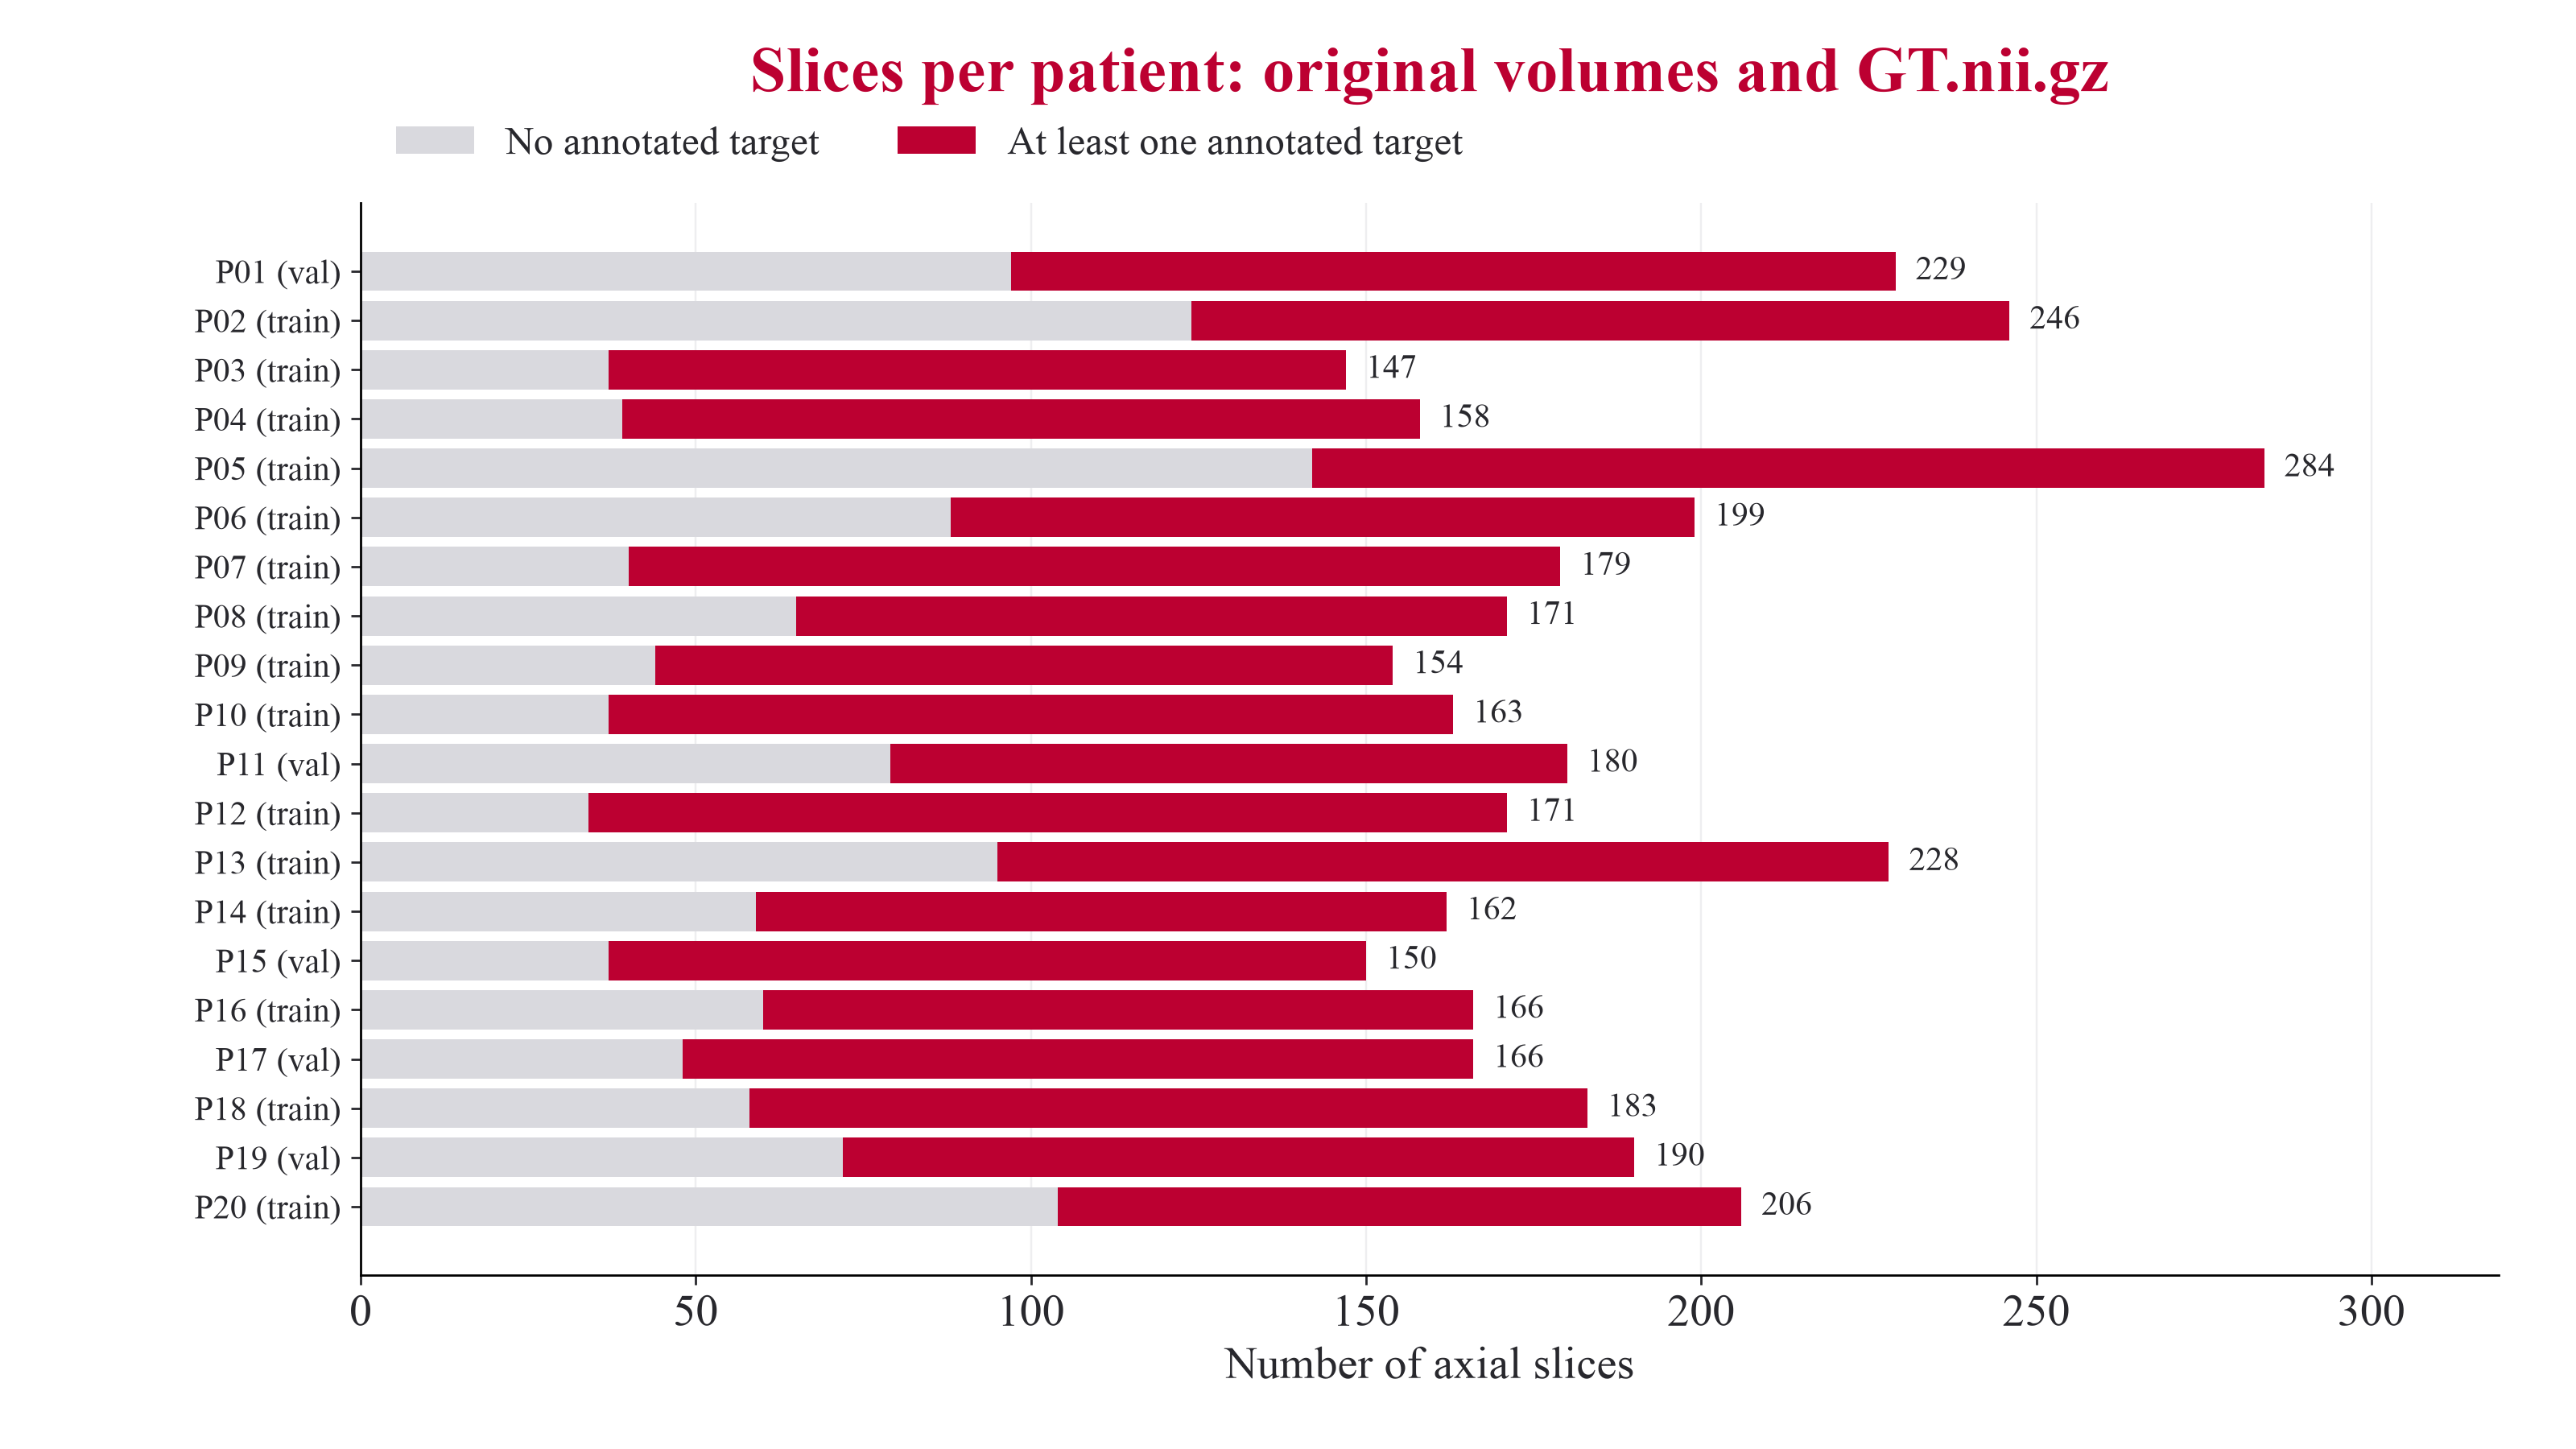

In [7]:
fig, ax = plt.subplots(figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.14, right=0.97, top=0.86, bottom=0.12)
labels = [r["patient"].replace("Patient_", "P") + (" (val)" if r["split"] == "validation" else " (train)") for r in patients]
bg_counts = np.array([r["background_only_slices"] for r in patients])
fg_counts = np.array([r["slices"] for r in patients]) - bg_counts
ax.barh(labels, bg_counts, color=LIGHT_GREY, label="No annotated target")
ax.barh(labels, fg_counts, left=bg_counts, color=UVA_RED, label="At least one annotated target")
for i, row in enumerate(patients):
    ax.text(row["slices"] + 3, i, str(row["slices"]), va="center", fontsize=12)
ax.invert_yaxis()
ax.set_xlim(0, max(r["slices"] for r in patients) + 35)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Number of axial slices")
ax.set_title("Slices per patient: original volumes and GT.nii.gz", pad=40)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.005), ncol=2, frameon=False, fontsize=14)
ax.set_axisbelow(True)
ax.grid(axis="x", color="#EEEEF0", linewidth=0.7)
save_figure(fig, "slices_per_patient.png")


#### 2. Foreground class imbalance

The denominator is **all voxels in each split**, including background. The aorta is part of the merged label, so a separate zero-sized aorta bar would be misleading.

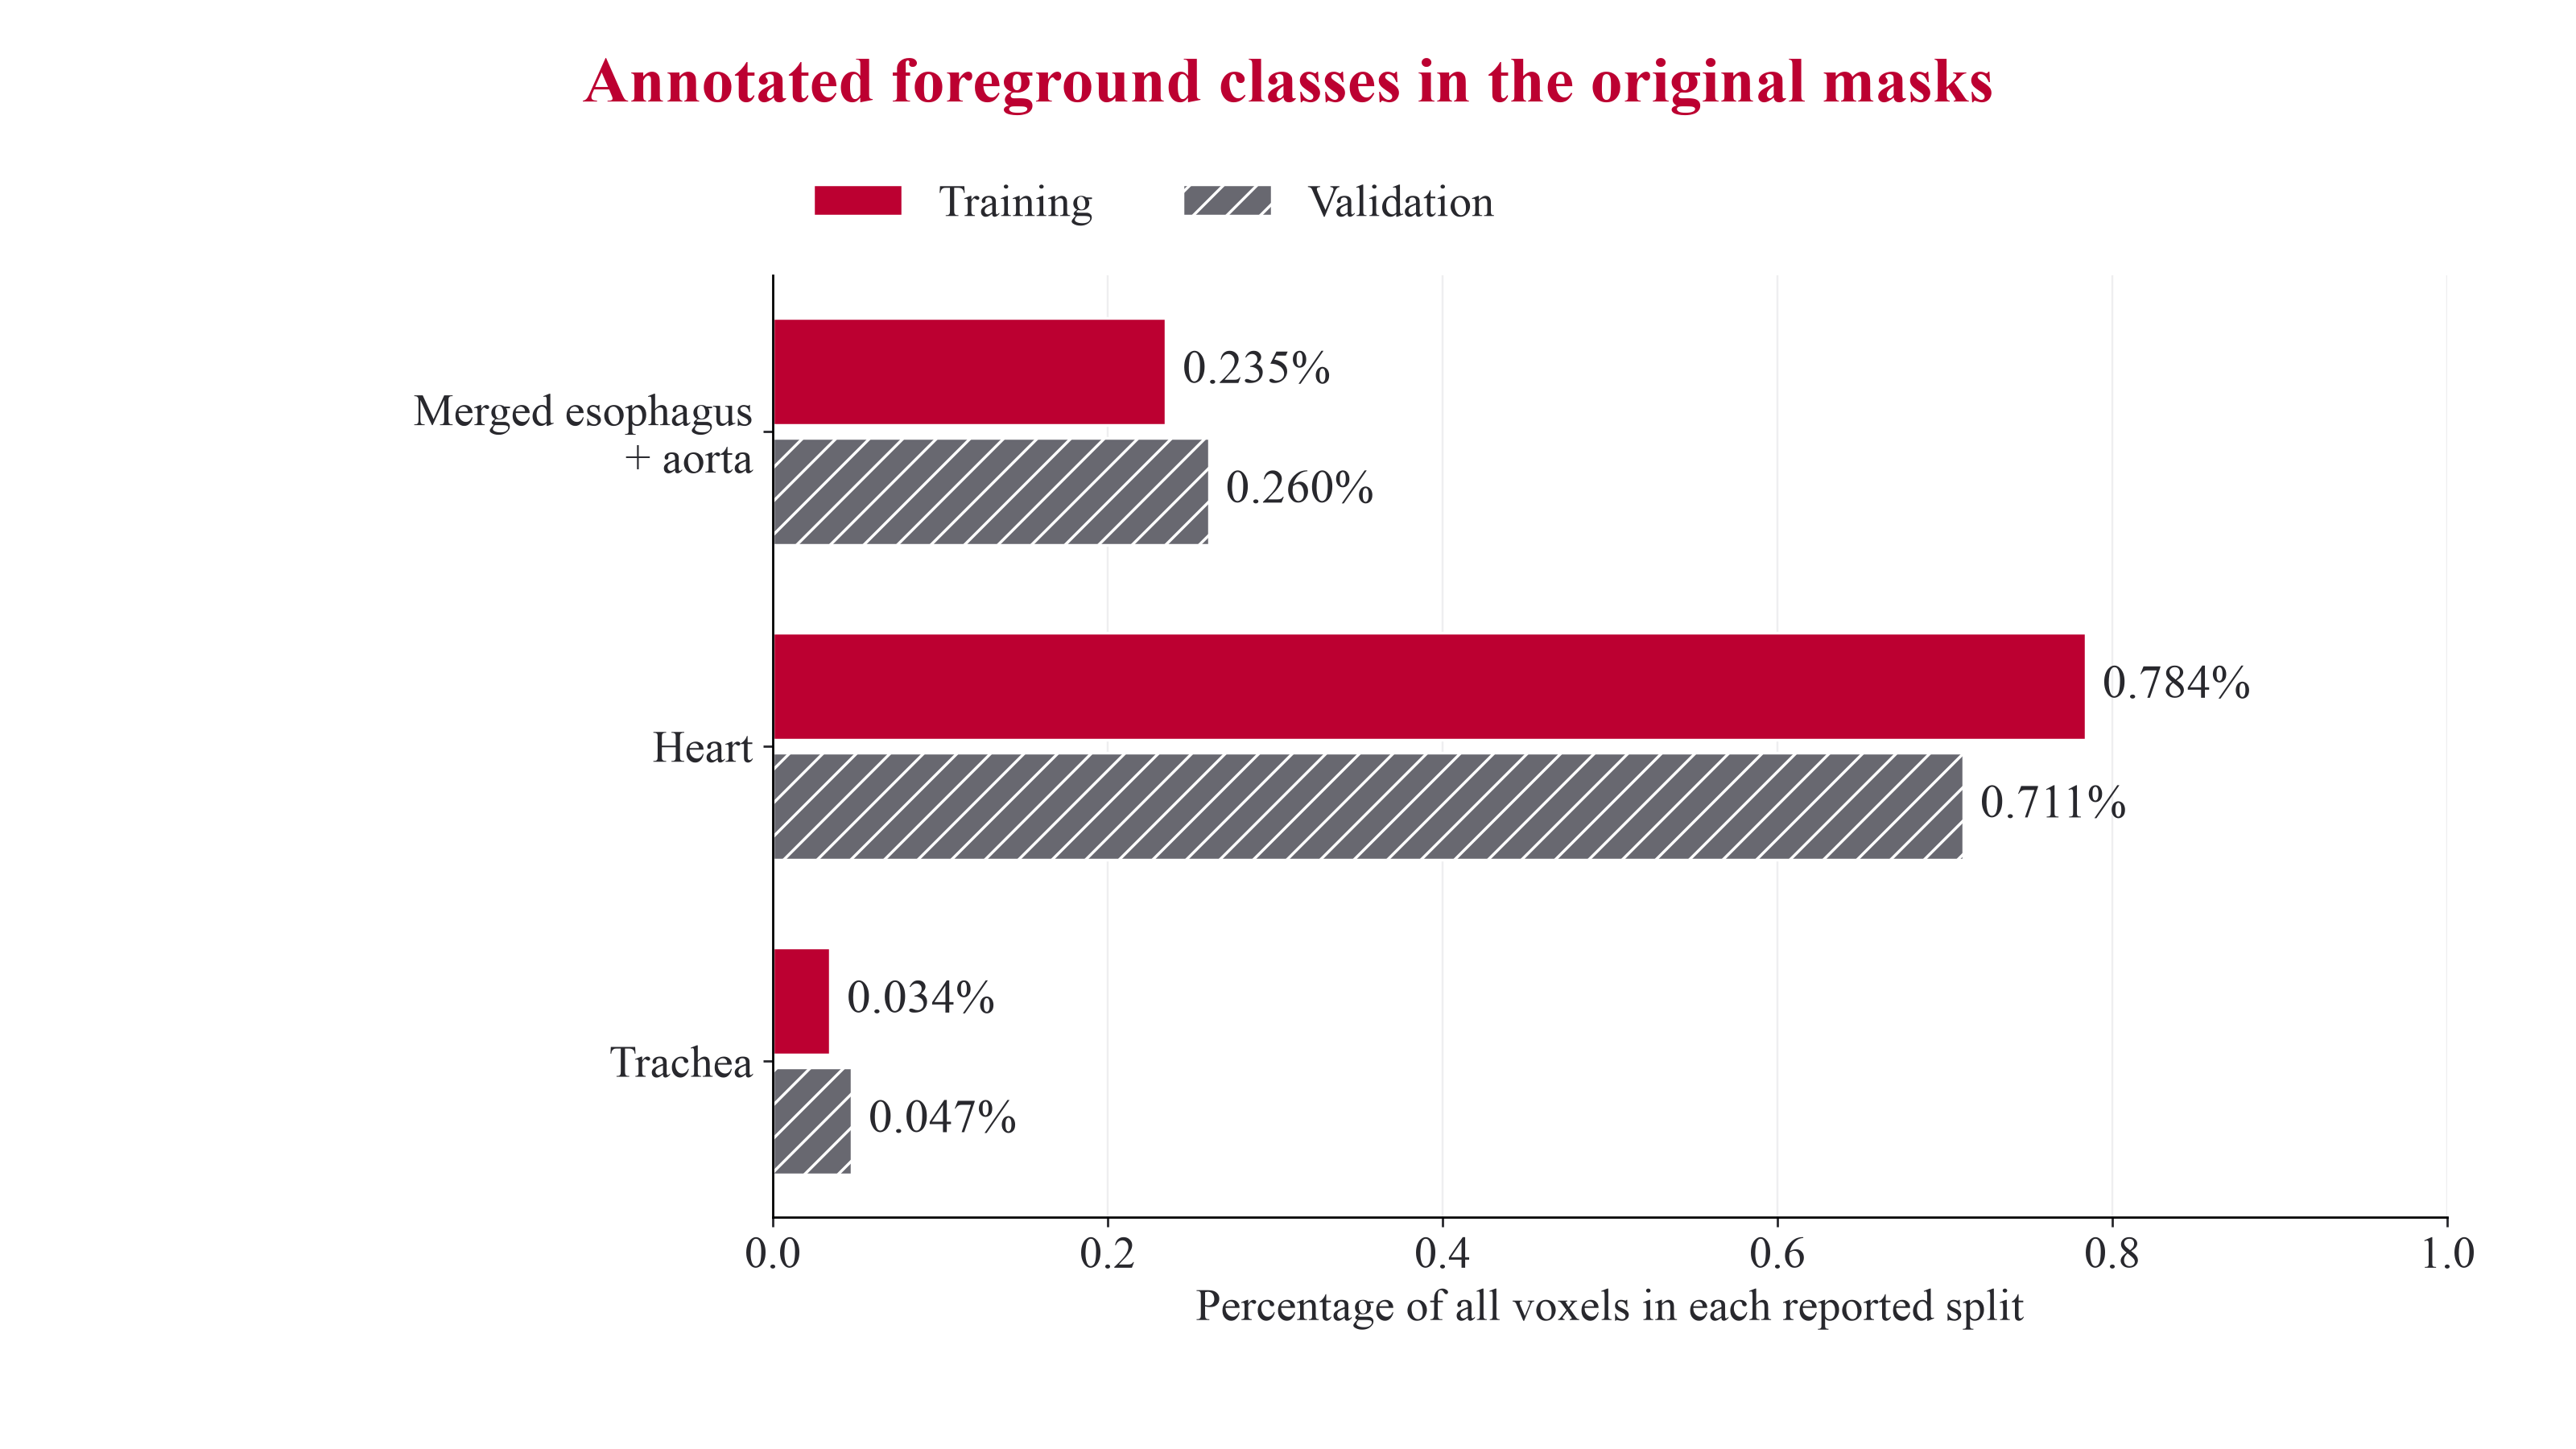

In [8]:
fig, ax = plt.subplots(figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.30, right=0.95, top=0.81, bottom=0.16)
names = ["Merged esophagus\n+ aorta", "Heart", "Trachea"]
positions = np.arange(3)
for offset, split, color, hatch in [(-0.19, "training", UVA_RED, None), (0.19, "validation", GREY, "//")]:
    values = [next(r["pooled_voxel_pct"] for r in pooled_classes if r["split"] == split and r["label"] == k) for k in (1, 2, 3)]
    bars = ax.barh(positions + offset, values, height=0.34, color=color, hatch=hatch, edgecolor="white", label=split.capitalize())
    ax.bar_label(bars, fmt="%.3f%%", padding=6, fontsize=17)
ax.set_yticks(positions, names)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Percentage of all voxels in each reported split")
fig.suptitle("Annotated foreground classes in the original masks", color=UVA_RED, fontsize=23, fontweight="bold", y=0.96)
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2)
ax.set_axisbelow(True)
ax.grid(axis="x", color="#EEEEF0", linewidth=0.7)
save_figure(fig, "foreground_class_shares.png")


#### 3. Dataset split summary

A compact table for the dataset-introduction slide. Patient counts and slice counts describe different units

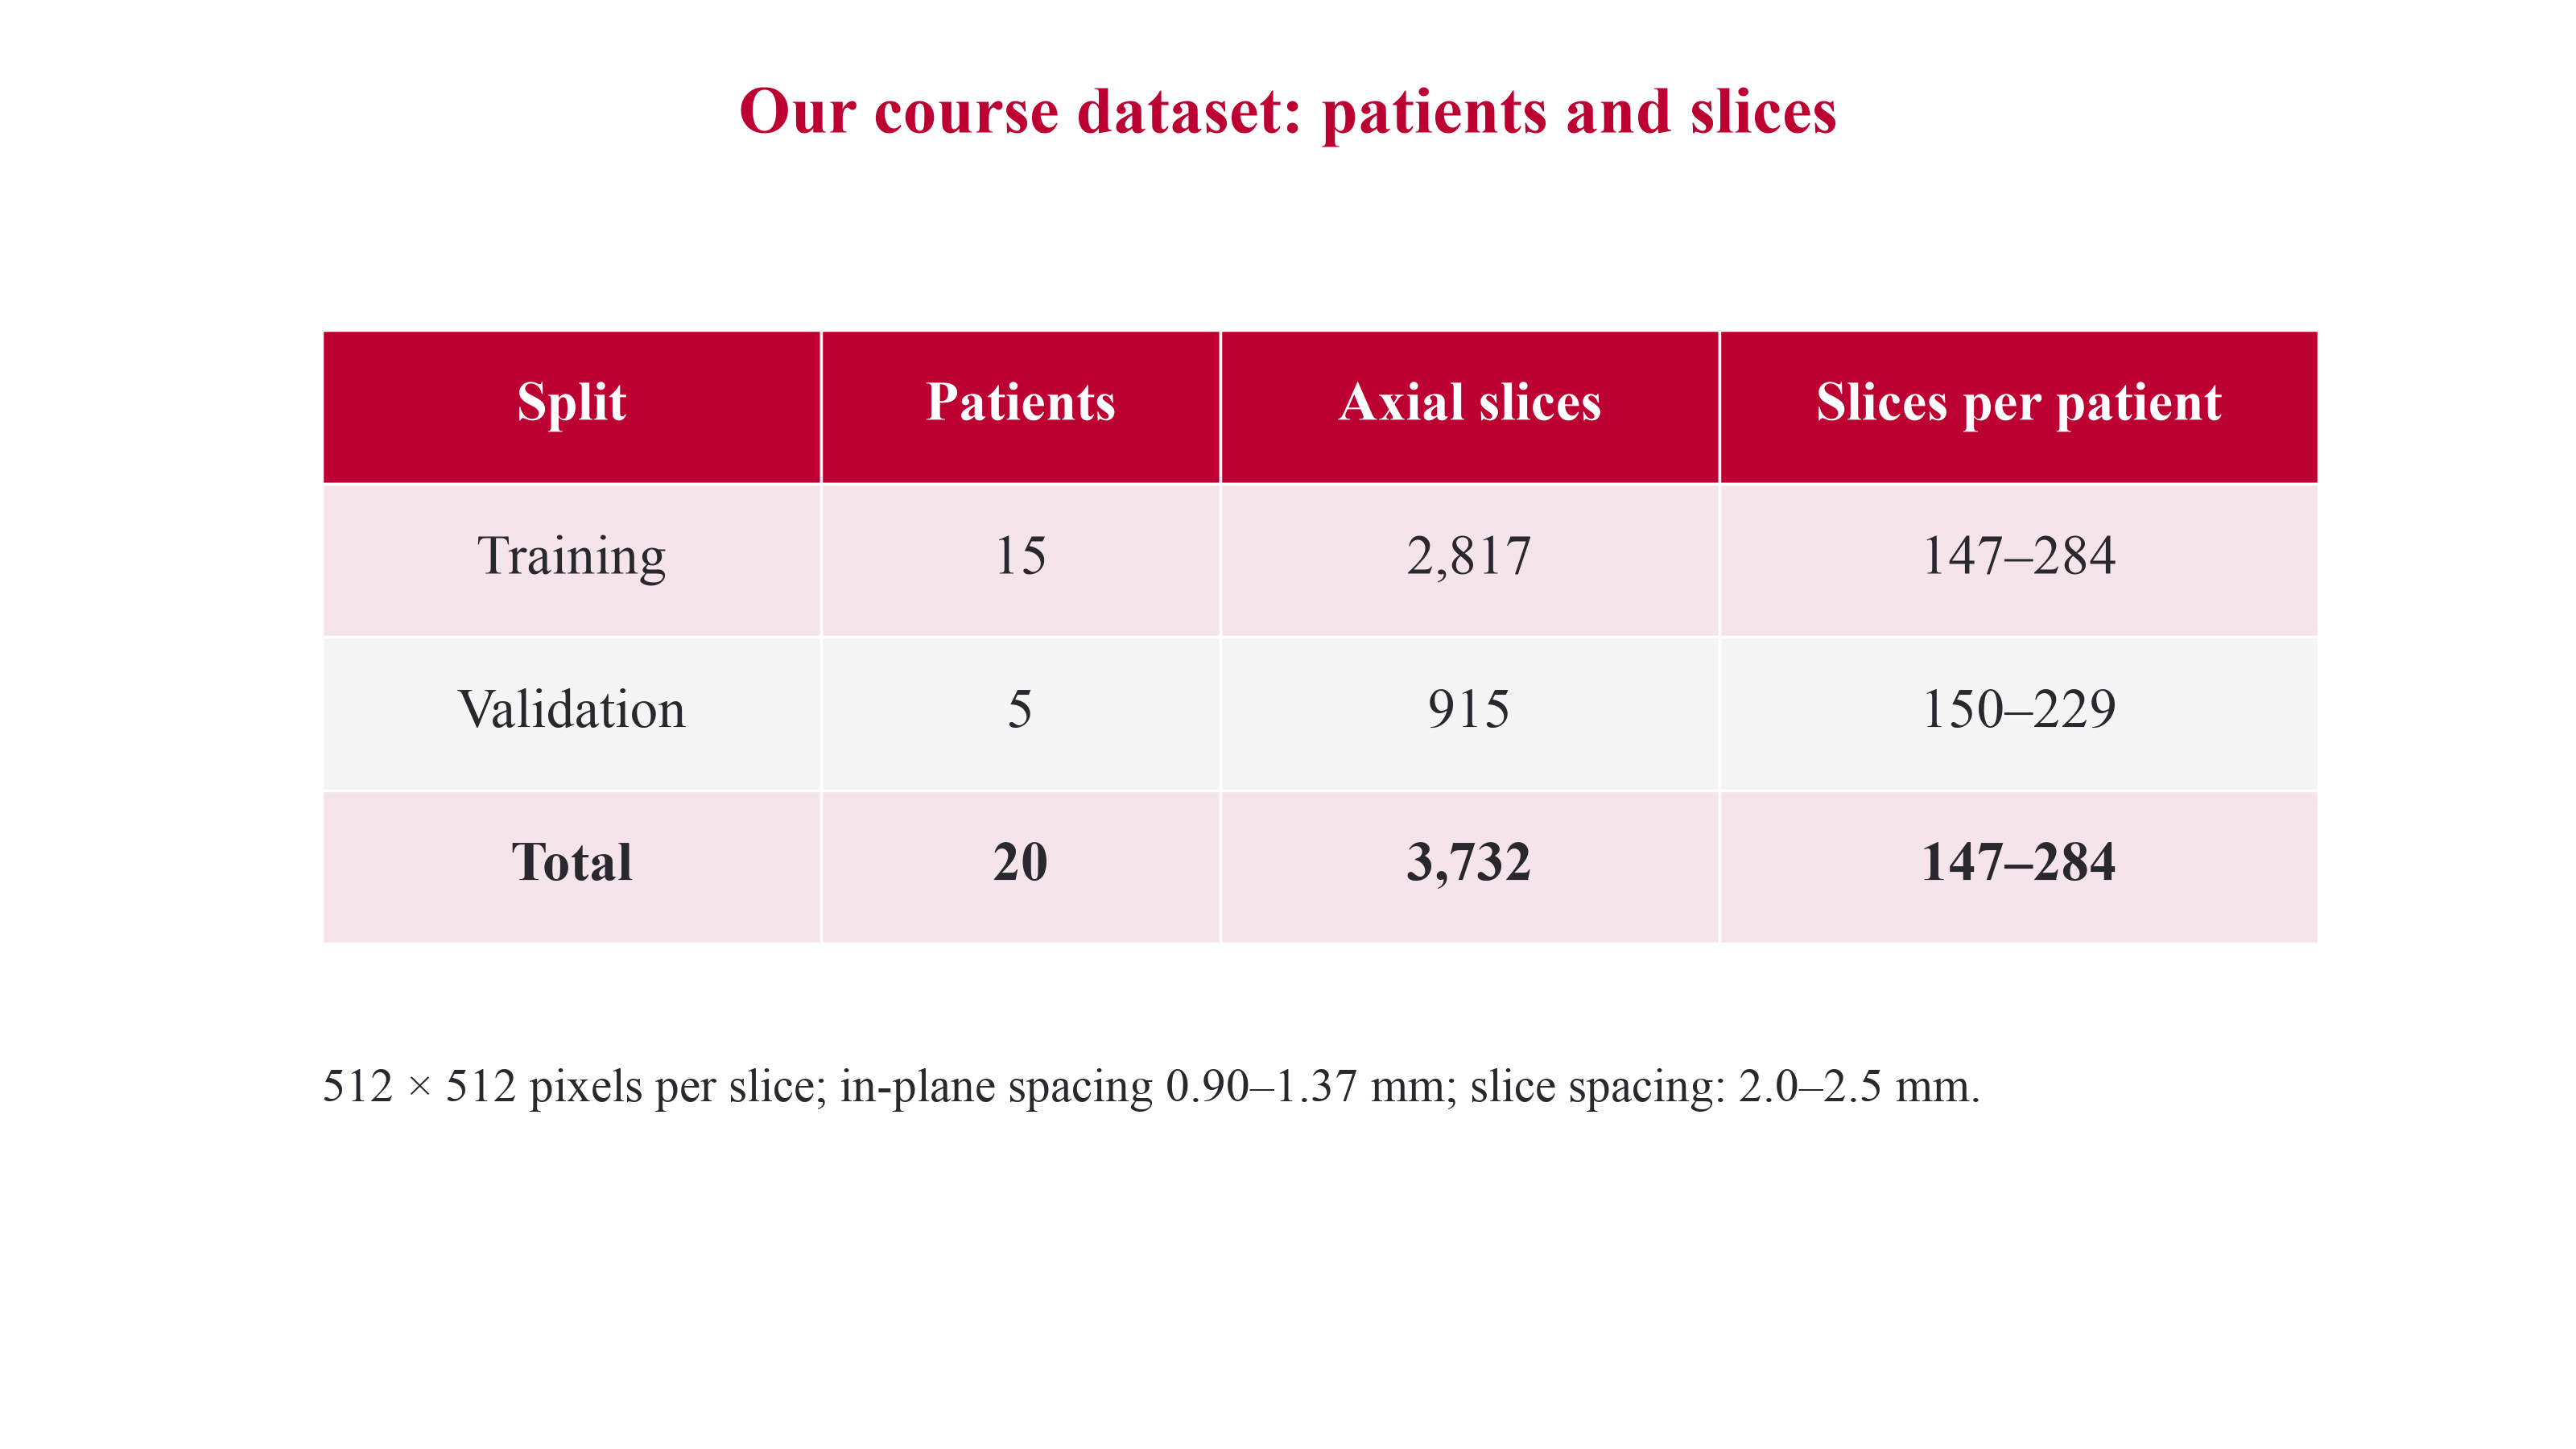

In [9]:
table_rows = []
for split in ("training", "validation", "all"):
    summary = next(r for r in summaries if r["split"] == split)
    selected = [r for r in patients if split == "all" or r["split"] == split]
    slice_counts = [r["slices"] for r in selected]
    table_rows.append(["Total" if split == "all" else split.capitalize(),
                       str(summary["patients"]), f'{summary["slices"]:,}',
                       f"{min(slice_counts)}–{max(slice_counts)}"])

fig, ax = plt.subplots(figsize=(12.8, 7.2))
ax.axis("off")
fig.suptitle("Our course dataset: patients and slices", color=UVA_RED, fontsize=24, fontweight="bold", y=0.94)
table = ax.table(cellText=table_rows,
                 colLabels=["Split", "Patients", "Axial slices", "Slices per patient"],
                 cellLoc="center", colWidths=[0.25, 0.20, 0.25, 0.30], bbox=[0, 0.31, 1, 0.55])
table.auto_set_font_size(False)
table.set_fontsize(20)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_facecolor(UVA_RED if row == 0 else (LIGHT_RED if row % 2 else "#F5F5F6"))
    if row == 0:
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
    if row == 3:
        cell.get_text().set_weight("bold")

xy = [r["spacing_x_mm"] for r in patients] + [r["spacing_y_mm"] for r in patients]
z = [r["spacing_z_mm"] for r in patients]
sizes = sorted({(r["size_x"], r["size_y"]) for r in patients})
image_size = ", ".join(f"{x} × {y}" for x, y in sizes)
fig.text(0.125, 0.24, f"{image_size} pixels per slice; in-plane spacing {min(xy):.2f}–{max(xy):.2f} mm; slice spacing: {min(z):.1f}–{max(z):.1f} mm.", fontsize=17)
save_figure(fig, "dataset_summary.png")


#### 4. Background voxels versus background-only slices

These are two different denominators. A slice containing an organ can still be almost entirely background. Background includes non-target anatomy, not just air.

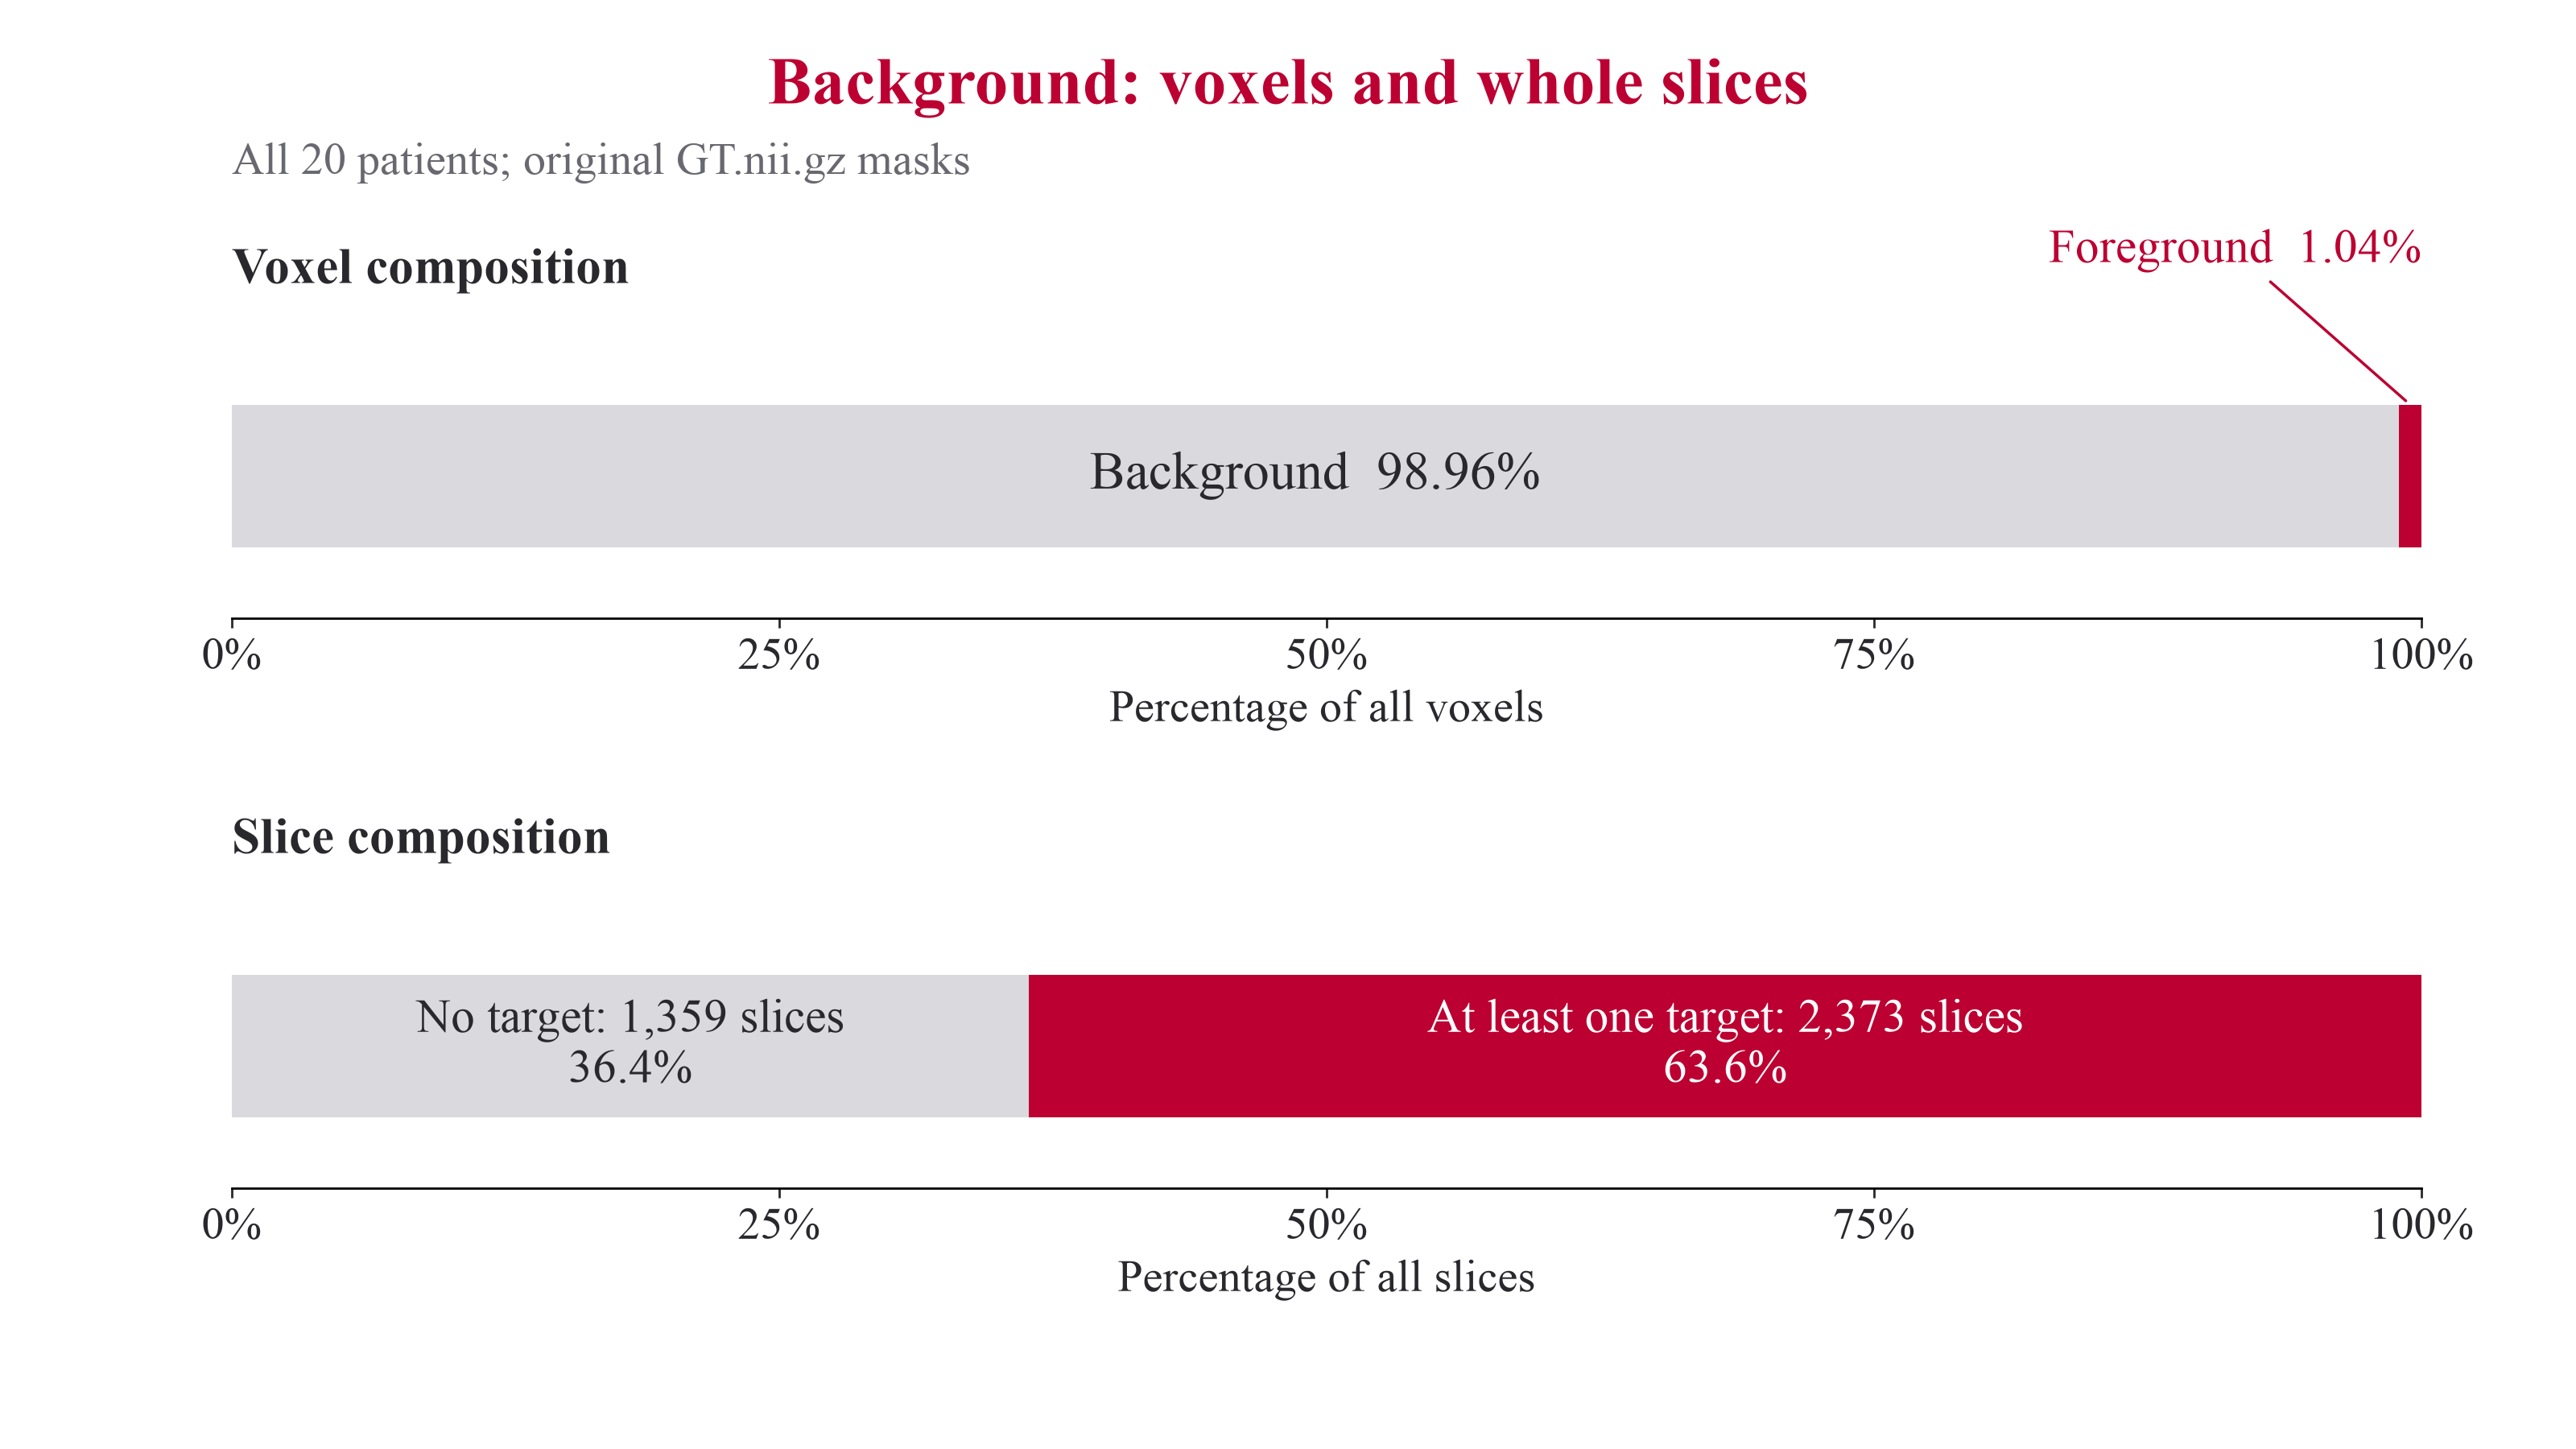

In [10]:
summary = next(r for r in summaries if r["split"] == "all")
bg_voxels = summary["background_voxel_pct"]
fg_voxels = summary["foreground_voxel_pct"]
bg_slices = summary["background_only_slice_pct"]
fg_slices = 100 - bg_slices
empty = summary["background_only_slices"]
nonempty = summary["slices"] - empty

fig, axes = plt.subplots(2, 1, figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.09, right=0.94, top=0.77, bottom=0.18, hspace=1.0)
fig.suptitle("Background: voxels and whole slices", color=UVA_RED, fontsize=24, fontweight="bold", y=0.96)
fig.text(0.09, 0.88, f'All {summary["patients"]} patients; original GT.nii.gz masks', color=GREY, fontsize=16)
for ax, bg, fg, unit in zip(axes, [bg_voxels, bg_slices], [fg_voxels, fg_slices], ["voxels", "slices"]):
    ax.barh(0, bg, height=0.5, color=LIGHT_GREY)
    ax.barh(0, fg, left=bg, height=0.5, color=UVA_RED)
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
    ax.set_xlabel(f"Percentage of all {unit}", fontsize=16)
    ax.spines["left"].set_visible(False)
axes[0].set_title("Voxel composition", loc="left", fontsize=18, color=DARK, pad=18)
axes[0].text(bg_voxels / 2, 0, f"Background  {bg_voxels:.2f}%", ha="center", va="center", fontsize=19)
axes[0].annotate(f"Foreground  {fg_voxels:.2f}%", xy=(bg_voxels + fg_voxels / 2, 0.25),
                 xytext=(100, 0.75), ha="right", fontsize=17, color=UVA_RED,
                 arrowprops={"arrowstyle": "-", "color": UVA_RED}, annotation_clip=False)
axes[1].set_title("Slice composition", loc="left", fontsize=18, color=DARK, pad=18)
axes[1].text(bg_slices / 2, 0, f"No target: {empty:,} slices\n{bg_slices:.1f}%", ha="center", va="center", fontsize=17)
axes[1].text(bg_slices + fg_slices / 2, 0, f"At least one target: {nonempty:,} slices\n{fg_slices:.1f}%", ha="center", va="center", fontsize=17, color="white")
save_figure(fig, "background_imbalance.png")


#### 5. The annotation issue

The ordinary masks use the same label for esophagus and aorta. Patient 7 has an additional GT2 mask that lets us verify the merge exactly. Separate organ proportions for the other patients cannot be recovered from these labels alone.

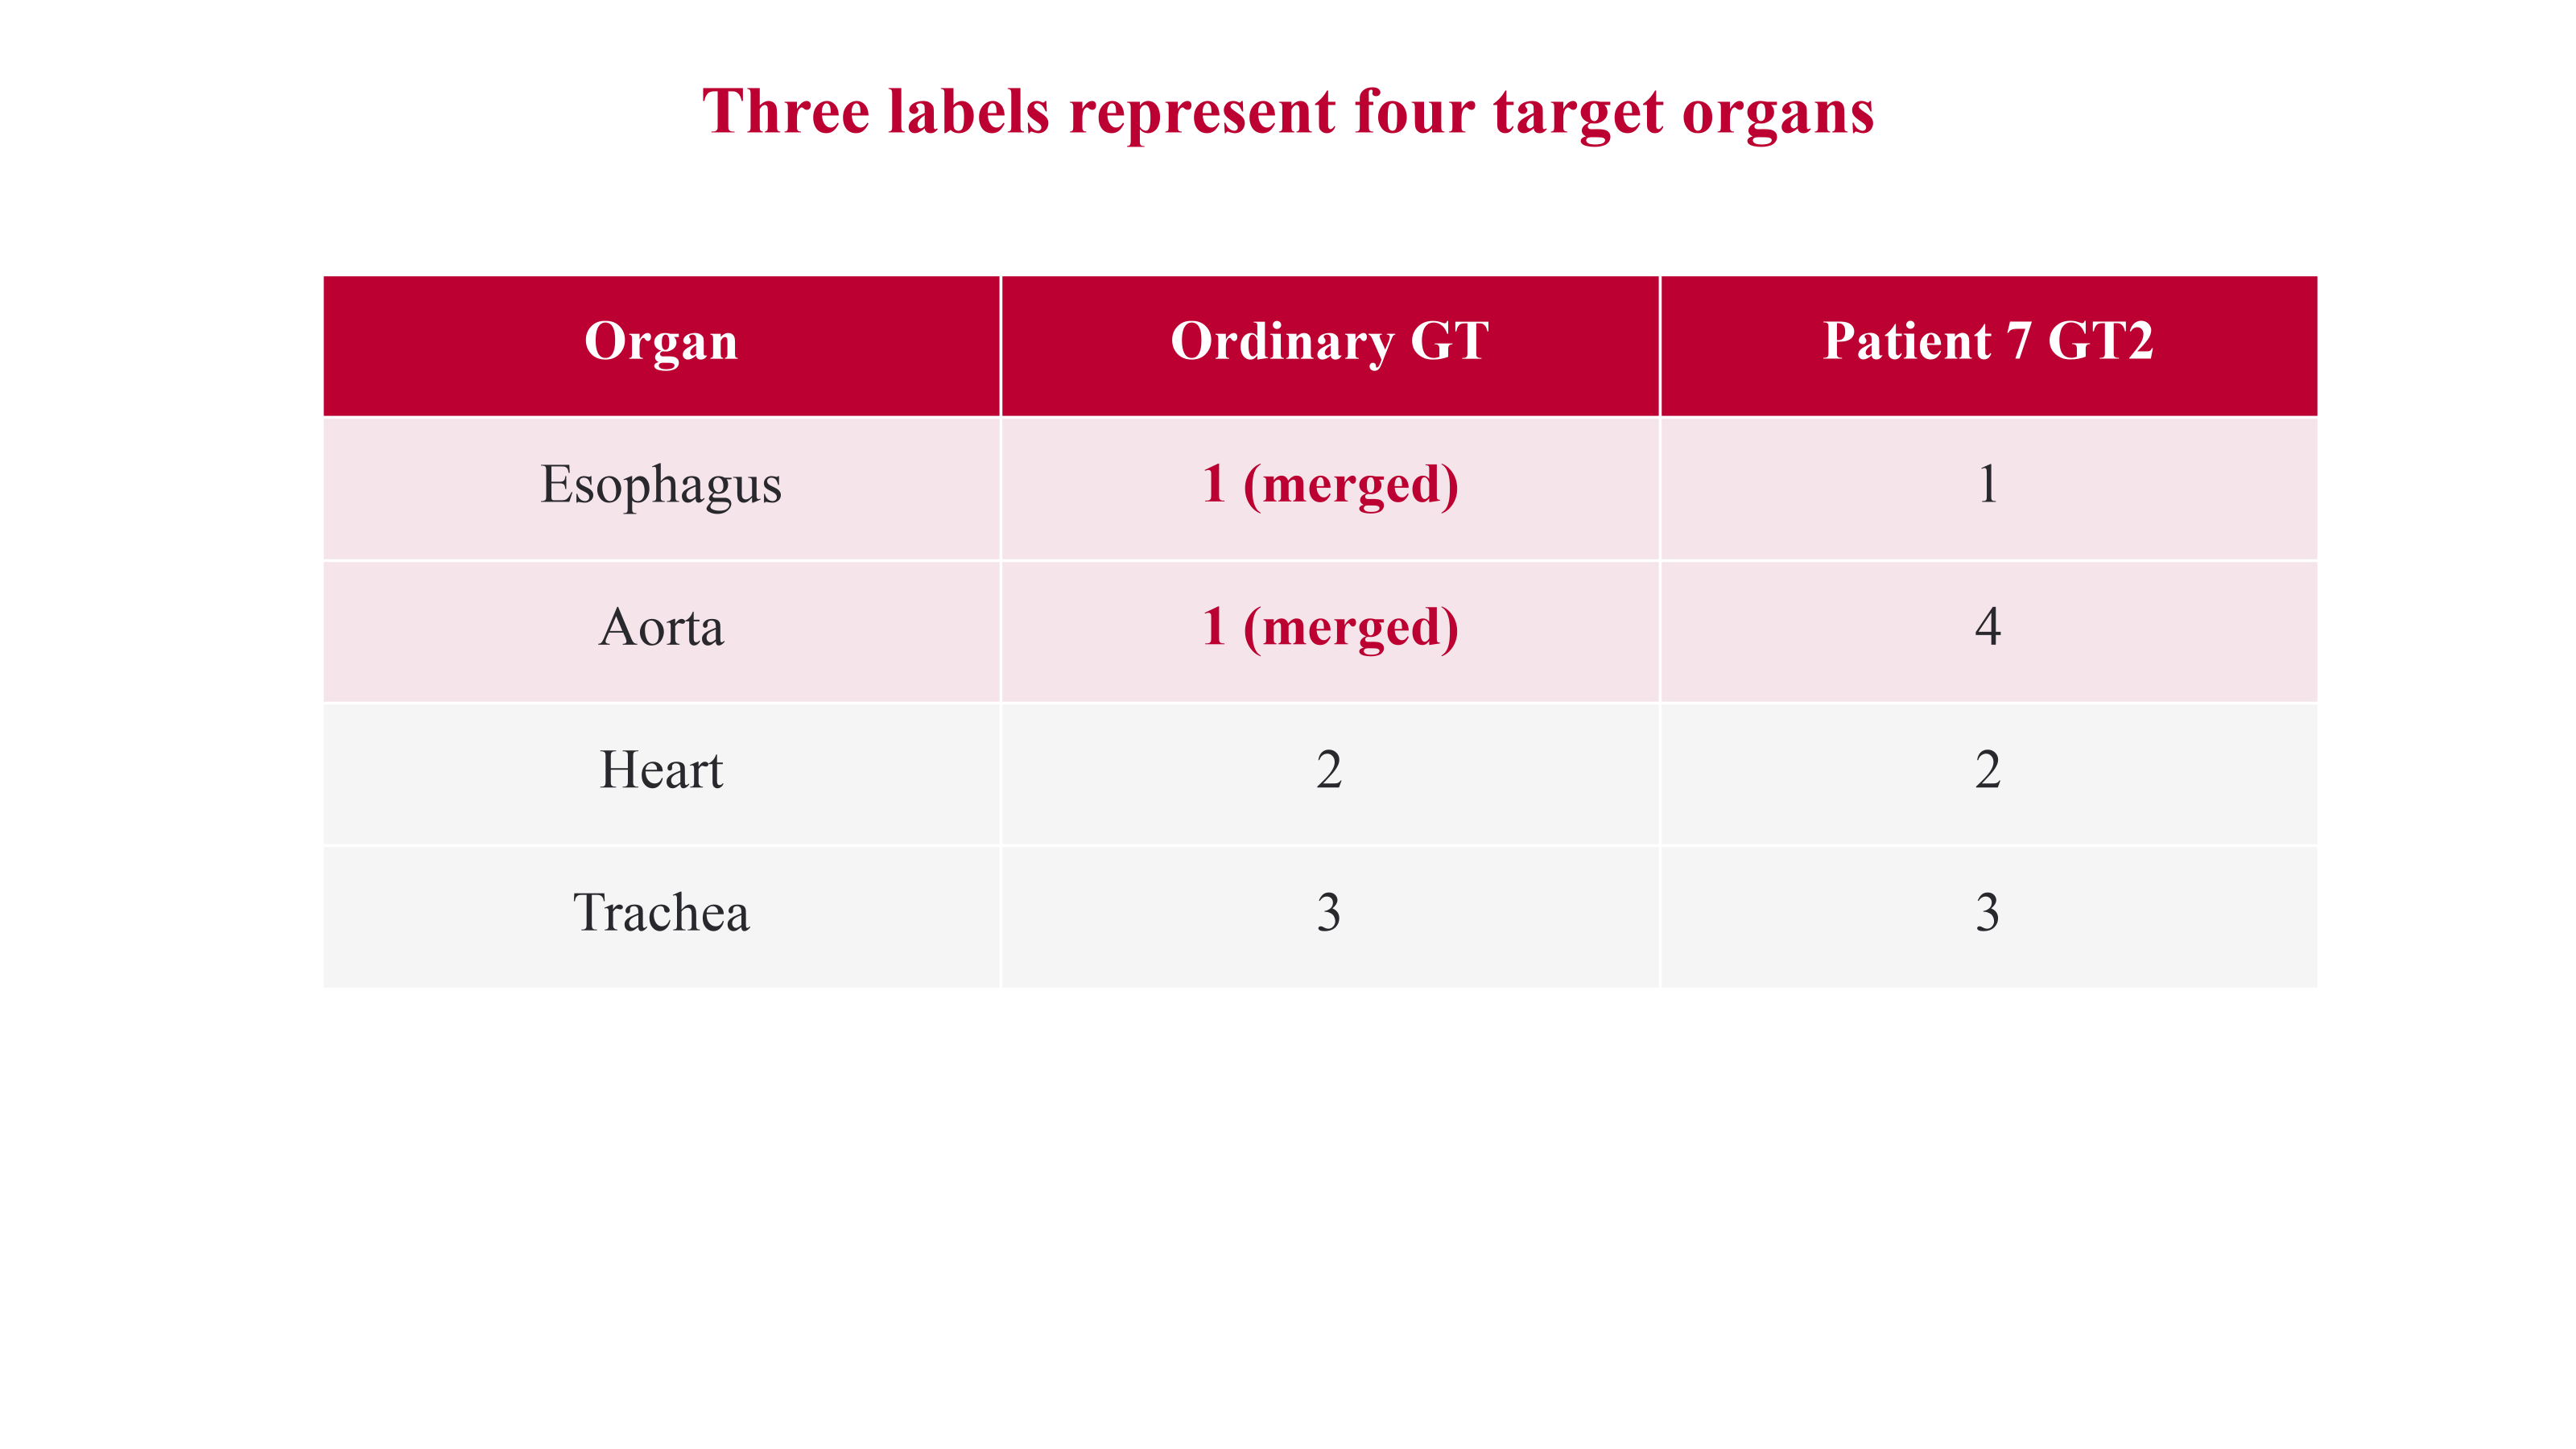

In [11]:
assert gt2_audit["gt_equals_gt2_with_4_mapped_to_1"], "The expected Patient 7 label merge was not confirmed"
mapping = [["Esophagus", "1 (merged)", "1"],
           ["Aorta", "1 (merged)", "4"],
           ["Heart", "2", "2"],
           ["Trachea", "3", "3"]]
fig, ax = plt.subplots(figsize=(12.8, 7.2))
ax.axis("off")
fig.suptitle("Three labels represent four target organs", color=UVA_RED, fontsize=24, fontweight="bold", y=0.94)
table = ax.table(cellText=mapping,
                 colLabels=["Organ", "Ordinary GT", "Patient 7 GT2"],
                 cellLoc="center", colWidths=[0.34, 0.33, 0.33], bbox=[0, 0.27, 1, 0.64])
table.auto_set_font_size(False)
table.set_fontsize(20)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_facecolor(UVA_RED if row == 0 else (LIGHT_RED if row in (1, 2) else "#F5F5F6"))
    if row == 0:
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
    if row in (1, 2) and col == 1:
        cell.get_text().set_color(UVA_RED)
        cell.get_text().set_weight("bold")
differences = gt2_audit["differing_voxels_after_remapping"]
save_figure(fig, "annotation_mapping.png")


#### 6. How often each label appears

This optional backup figure answers a different question from class voxel share: how many **slices** contain each label? Several labels can occur in one slice, so these percentages overlap.

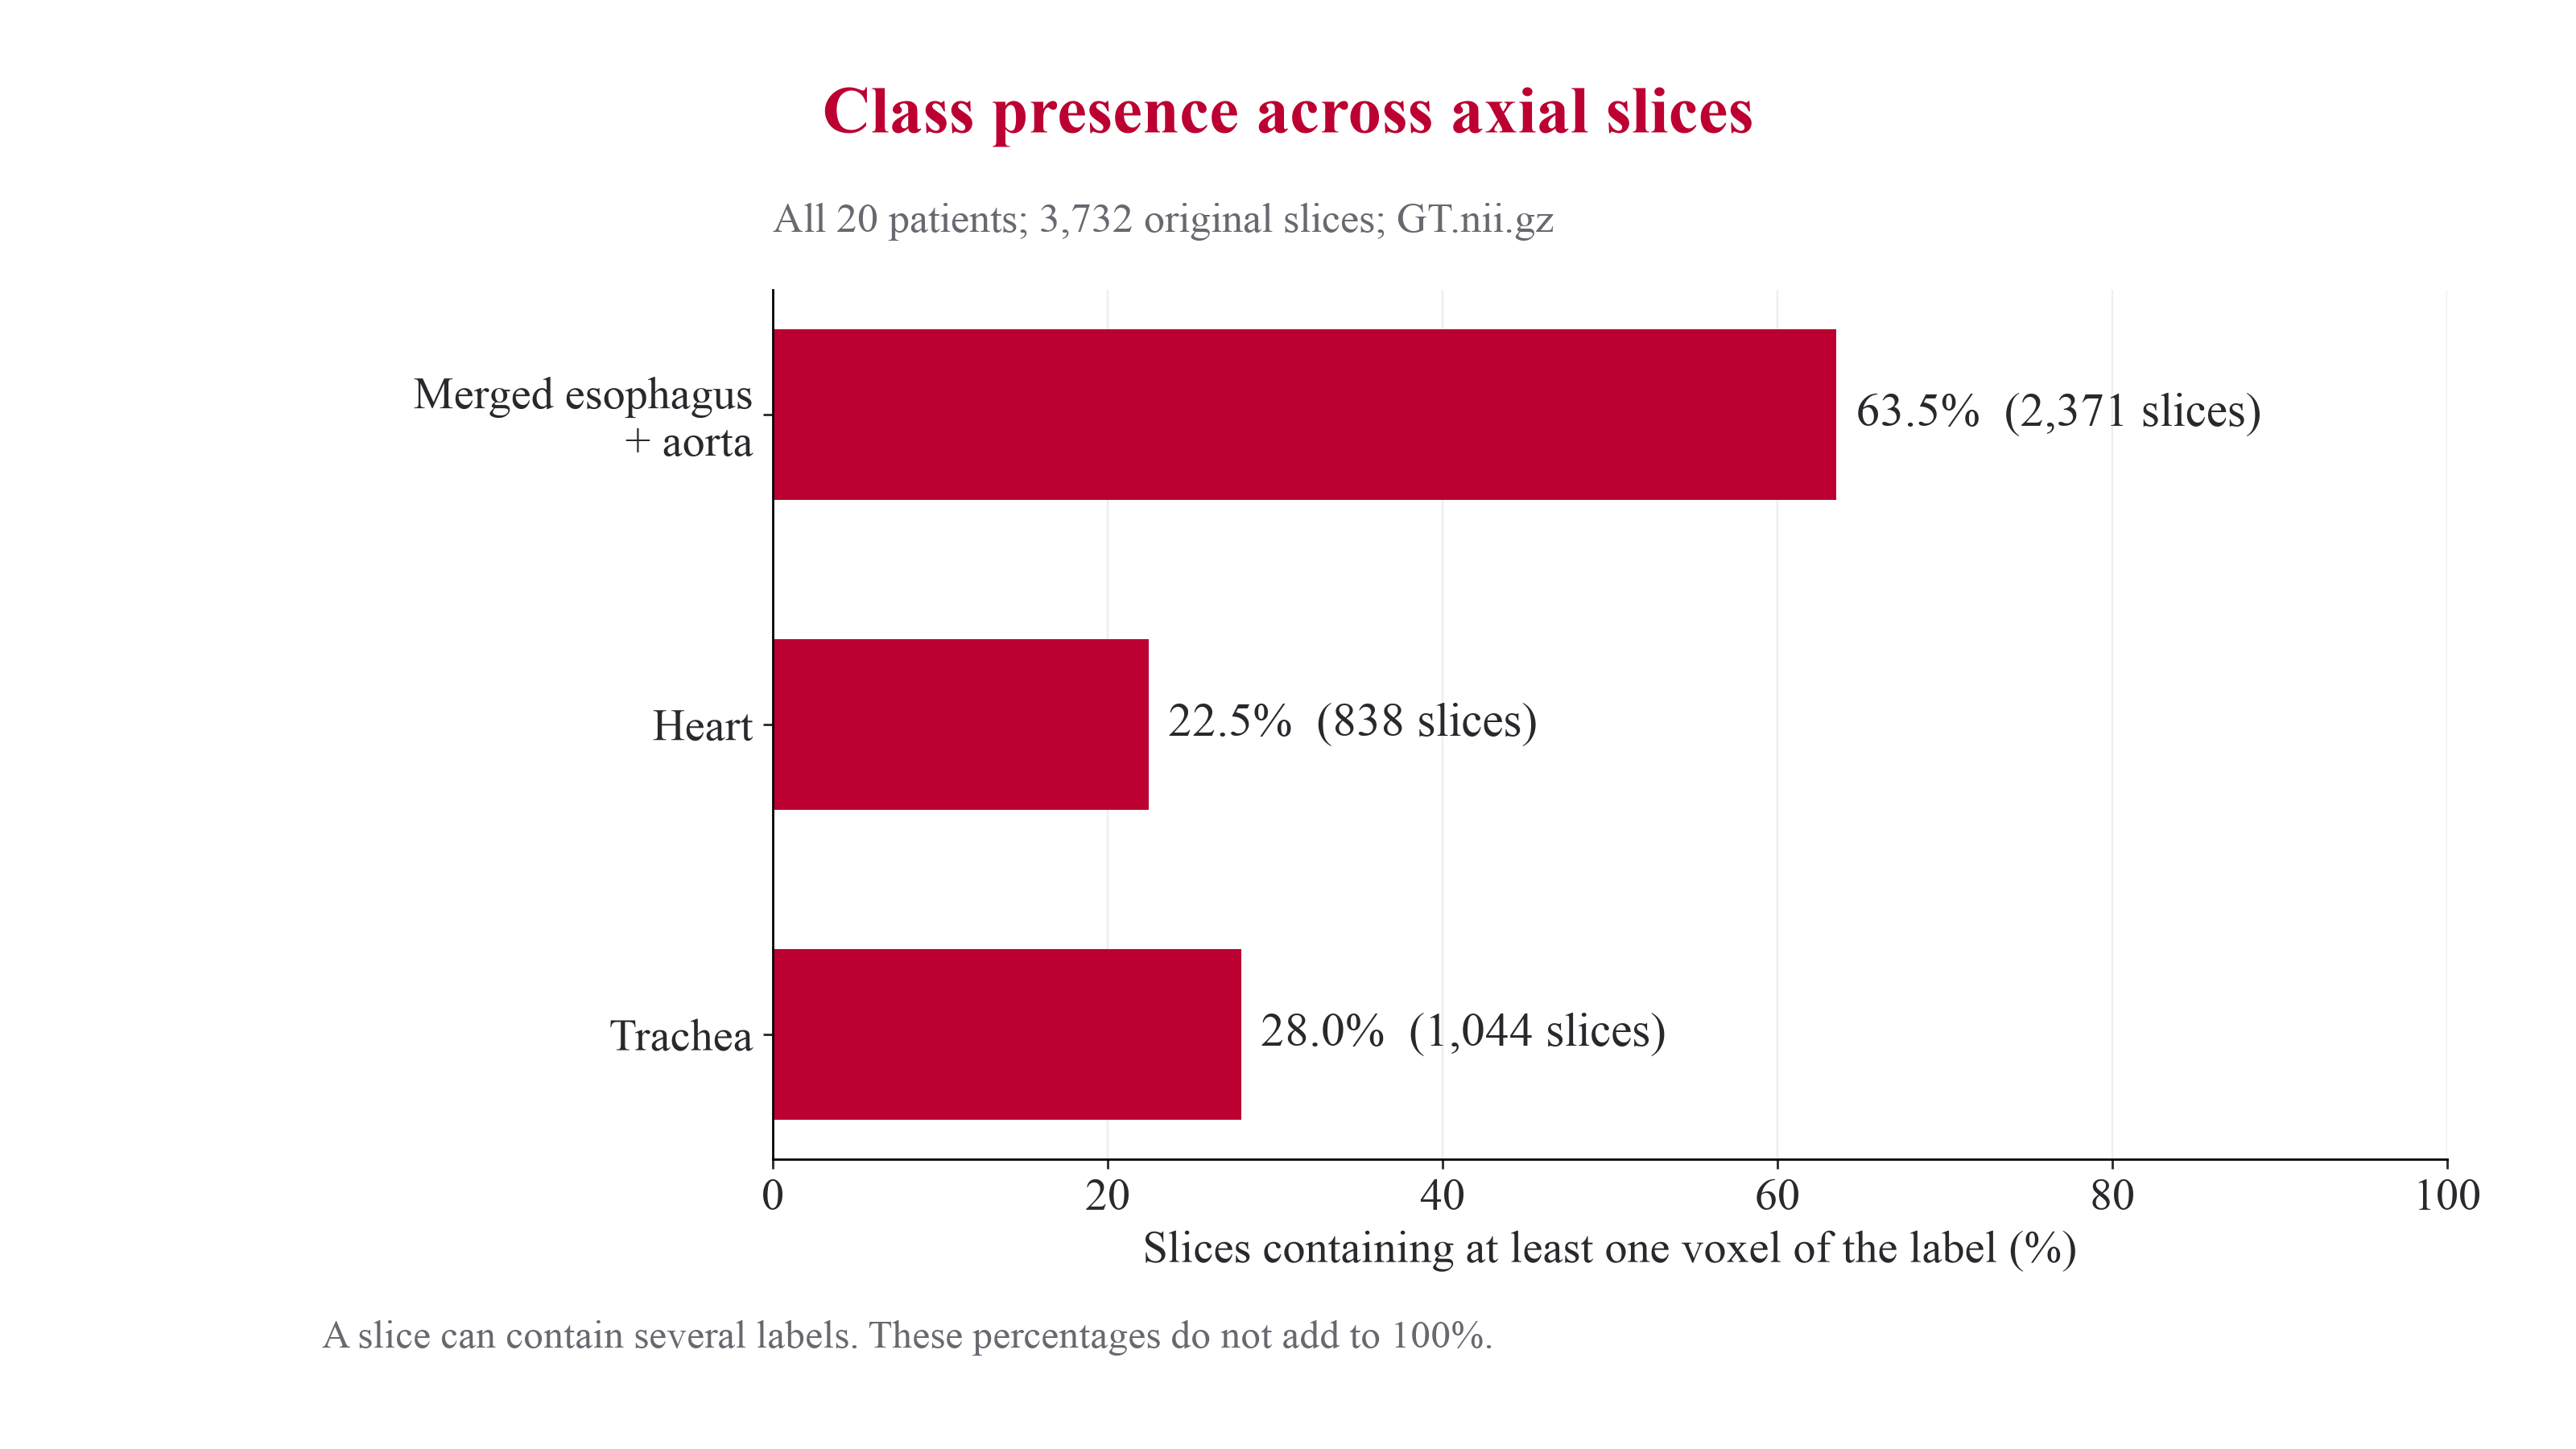

In [12]:
rows = [next(r for r in pooled_classes if r["split"] == "all" and r["label"] == k) for k in (1, 2, 3)]
values = [r["slice_presence_pct"] for r in rows]
counts = [sum(r["slices_with_label"] for r in class_rows if r["label"] == k) for k in (1, 2, 3)]
fig, ax = plt.subplots(figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.30, right=0.95, top=0.80, bottom=0.20)
bars = ax.barh(["Merged esophagus\n+ aorta", "Heart", "Trachea"], values, color=UVA_RED, height=0.55)
ax.bar_label(bars, labels=[f"{value:.1f}%  ({count:,} slices)" for value, count in zip(values, counts)], padding=7, fontsize=17)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Slices containing at least one voxel of the label (%)")
fig.suptitle("Class presence across axial slices", color=UVA_RED, fontsize=24, fontweight="bold", y=0.94)
fig.text(0.30, 0.84, f'All {len(patients)} patients; {len(slice_rows):,} original slices; GT.nii.gz', color=GREY, fontsize=15)
ax.set_axisbelow(True)
ax.grid(axis="x", color="#EEEEF0", linewidth=0.7)
fig.text(0.125, 0.07, "A slice can contain several labels. These percentages do not add to 100%.", color=GREY, fontsize=14)
save_figure(fig, "class_slice_presence.png")


#### 7. HU Values

In [10]:
# Store statistics of each patient file
stats = []

for folder in folders:
    ct = nib.load(folder / f"{folder.name}.nii.gz")   
    # Use less memory (float32 instead of float64)
    data = ct.get_fdata(dtype='float32')
    stats.append({
        'patient': folder.name,
        'mean': data.mean(),
        'std': data.std(),
        'min': data.min(),
        'max': data.max()
    })

# Print a clean table
print(f"{'Patient':<40}{'Mean':>10}{'Std':>10}{'Min':>10}{'Max':>10}")
for s in stats:
    print(f"{s['patient']:<40}{s['mean']:>10.2f}{s['std']:>10.2f}{s['min']:>10.2f}{s['max']:>10.2f}")

Patient                                       Mean       Std       Min       Max
Patient_01                                 -746.23    417.73  -1000.00   3071.00
Patient_02                                 -689.51    450.99  -1000.00  26613.00
Patient_03                                 -738.09    413.40  -1000.00  25292.00
Patient_04                                 -714.44    421.32  -1000.00   4551.00
Patient_05                                 -795.65    405.47  -1000.00   3071.00
Patient_06                                 -741.80    435.12  -1000.00   3071.00
Patient_07                                 -720.41    420.73  -1000.00   3059.00
Patient_08                                 -764.88    415.71  -1000.00   3071.00
Patient_09                                 -779.99    410.91  -1000.00   3071.00
Patient_10                                 -630.85    467.69  -1000.00   3071.00
Patient_11                                 -757.77    392.55  -1000.00   8834.00
Patient_12                  